In [1]:
import pandas as pd
import numpy as np

### LOADING CSV DATASET & ASSIGNING CORRECT DATA TYPES

In [2]:
data = pd.read_csv('customer_churn_data.csv')
data.head()

,Customer_ID,Gender,Senior_Citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Customer_Feedback,Churn_Status
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Unsatisfied,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,Satisfied,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Unsatisfied,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Satisfied,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Unsatisfied,Yes


In [3]:
missing_values = data.isnull().sum()
print('Missing Values:')
missing_values

Missing Values:


Customer_ID          0
Gender               0
Senior_Citizen       0
Partner              0
Dependents           0
Tenure               0
Phone_Service        0
Multiple_Lines       0
Internet_Service     0
Online_Security      0
Online_Backup        0
Device_Protection    0
Tech_Support         0
Streaming_TV         0
Streaming_Movies     0
Contract             0
Paperless_Billing    0
Payment_Method       0
Monthly_Charges      0
Total_Charges        0
Customer_Feedback    0
Churn_Status         0
dtype: int64

In [4]:
data.dtypes

Customer_ID           object
Gender                object
Senior_Citizen         int64
Partner               object
Dependents            object
Tenure                 int64
Phone_Service         object
Multiple_Lines        object
Internet_Service      object
Online_Security       object
Online_Backup         object
Device_Protection     object
Tech_Support          object
Streaming_TV          object
Streaming_Movies      object
Contract              object
Paperless_Billing     object
Payment_Method        object
Monthly_Charges      float64
Total_Charges         object
Customer_Feedback     object
Churn_Status          object
dtype: object

In [5]:
data['Total_Charges'] = data['Total_Charges'].str.strip()

In [6]:
data['Total_Charges'] = pd.to_numeric(data['Total_Charges'], errors = 'coerce')

In [7]:
data['Total_Charges'].isnull().sum()

np.int64(11)

In [8]:
data['Total_Charges'] = data['Total_Charges'].fillna(data['Total_Charges'].median())

In [9]:
data['Total_Charges'].isnull().sum()

np.int64(0)

In [10]:
data['Total_Charges'].dtype

dtype('float64')

In [11]:
data[['Monthly_Charges', 'Total_Charges']].head()

,Monthly_Charges,Total_Charges
0,29.85,29.85
1,56.95,1889.50
2,53.85,108.15
3,42.30,1840.75
4,70.70,151.65


In [12]:
duplicates = data.duplicated()
data[duplicates]

,Customer_ID,Gender,Senior_Citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Customer_Feedback,Churn_Status


### FINDING UNIQUE VALUES AND IDENTIFY COLUMNS WITH UNNECESSARY CATEGORIES

In [13]:
data.nunique()

Customer_ID          7043
Gender                  2
Senior_Citizen          2
Partner                 2
Dependents              2
Tenure                 73
Phone_Service           2
Multiple_Lines          3
Internet_Service        3
Online_Security         3
Online_Backup           3
Device_Protection       3
Tech_Support            3
Streaming_TV            3
Streaming_Movies        3
Contract                3
Paperless_Billing       2
Payment_Method          4
Monthly_Charges      1585
Total_Charges        6531
Customer_Feedback       3
Churn_Status            2
dtype: int64

### EXPLORATORY DATA ANALYSIS (EDA)

In [14]:
data.head()

,Customer_ID,Gender,Senior_Citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Customer_Feedback,Churn_Status
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Unsatisfied,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,Satisfied,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Unsatisfied,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Satisfied,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Unsatisfied,Yes


### Frequency & Percenatge Analysis

In [15]:
def freq_percent(col):
    freq = data[col].value_counts()
    percent = data[col].value_counts(normalize = True) * 100
    table = pd.DataFrame({'Frequency': freq,
                         'Percentage (%)': percent.round(2)})
    return table

In [16]:
print('=== Churn Status Frequency & Percentage Analysis ===')
freq_percent('Churn_Status')

=== Churn Status Frequency & Percentage Analysis ===


,Frequency,Percentage (%)
Churn_Status,,
No,5174,73.46
Yes,1869,26.54


In [17]:
print('=== Contract Frequency & Percentage Analysis ===')
freq_percent('Contract')

=== Contract Frequency & Percentage Analysis ===


,Frequency,Percentage (%)
Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91


In [18]:
print('=== Customer Feedback Frequency & Percentage Analysis ===')
freq_percent('Customer_Feedback')

=== Customer Feedback Frequency & Percentage Analysis ===


,Frequency,Percentage (%)
Customer_Feedback,,
Satisfied,3366,47.79
Unsatisfied,2939,41.73
Neutral,738,10.48


In [19]:
print('=== Payment Method Frequency & Percentage Analysis ===')
freq_percent('Payment_Method')

=== Payment Method Frequency & Percentage Analysis ===


,Frequency,Percentage (%)
Payment_Method,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61


In [20]:
print('=== Internet Service Frequency & Percentage Analysis ===')
freq_percent('Internet_Service')

=== Internet Service Frequency & Percentage Analysis ===


,Frequency,Percentage (%)
Internet_Service,,
Fiber optic,3096,43.96
DSL,2421,34.37
No,1526,21.67


In [21]:
print('=== Multiple Lines Frequency & Percentage Analysis ===')
freq_percent('Multiple_Lines')

=== Multiple Lines Frequency & Percentage Analysis ===


,Frequency,Percentage (%)
Multiple_Lines,,
No,3390,48.13
Yes,2971,42.18
No phone service,682,9.68


In [22]:
print('=== Partner Frequency & Percentage Analysis ===')
freq_percent('Partner')

=== Partner Frequency & Percentage Analysis ===


,Frequency,Percentage (%)
Partner,,
No,3641,51.7
Yes,3402,48.3


In [23]:
print('=== Dependents Frequency & Percentage Analysis ===')
freq_percent('Dependents')

=== Dependents Frequency & Percentage Analysis ===


,Frequency,Percentage (%)
Dependents,,
No,4933,70.04
Yes,2110,29.96


In [24]:
print('=== Paperless Billing Frequency & Percentage Analysis ===')
freq_percent('Paperless_Billing')

=== Paperless Billing Frequency & Percentage Analysis ===


,Frequency,Percentage (%)
Paperless_Billing,,
Yes,4171,59.22
No,2872,40.78


### Descriptive Statistics & Analysis

In [25]:
data.dtypes

Customer_ID           object
Gender                object
Senior_Citizen         int64
Partner               object
Dependents            object
Tenure                 int64
Phone_Service         object
Multiple_Lines        object
Internet_Service      object
Online_Security       object
Online_Backup         object
Device_Protection     object
Tech_Support          object
Streaming_TV          object
Streaming_Movies      object
Contract              object
Paperless_Billing     object
Payment_Method        object
Monthly_Charges      float64
Total_Charges        float64
Customer_Feedback     object
Churn_Status          object
dtype: object

In [26]:
numeric_cols = ['Tenure', 'Monthly_Charges', 'Total_Charges']

In [27]:
data[numeric_cols].describe().round(2)

,Tenure,Monthly_Charges,Total_Charges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2281.92
std,24.56,30.09,2265.27
min,0.00,18.25,18.80
25%,9.00,35.50,402.22
50%,29.00,70.35,1397.48
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


### Group By Data Analysis Method

In [28]:
print('=== Churn Status Groupby Analysis ===')
data.groupby('Churn_Status')[['Tenure', 'Monthly_Charges', 'Total_Charges']].mean().round(2)

=== Churn Status Groupby Analysis ===


,Tenure,Monthly_Charges,Total_Charges
Churn_Status,,,
No,37.57,61.27,2552.88
Yes,17.98,74.44,1531.80


In [29]:
print('=== Contract Groupby Analysis ===')
data.groupby('Contract')[['Tenure', 'Monthly_Charges', 'Total_Charges']].mean().round(2)

=== Contract Groupby Analysis ===


,Tenure,Monthly_Charges,Total_Charges
Contract,,,
Month-to-month,18.04,66.40,1369.25
One year,42.04,65.05,3033.57
Two year,56.74,60.77,3715.18


In [30]:
print('=== Customer Feedback Groupby Analysis ===')
data.groupby('Customer_Feedback')[['Tenure', 'Monthly_Charges', 'Total_Charges']].mean().round(2)

=== Customer Feedback Groupby Analysis ===


,Tenure,Monthly_Charges,Total_Charges
Customer_Feedback,,,
Neutral,17.35,53.62,939.91
Satisfied,52.39,67.58,3636.80
Unsatisfied,13.22,64.34,1067.17


In [31]:
print('=== Internet Service Groupby Analysis ===')
data.groupby('Internet_Service')[['Tenure', 'Monthly_Charges', 'Total_Charges']].mean().round(2)

=== Internet Service Groupby Analysis ===


,Tenure,Monthly_Charges,Total_Charges
Internet_Service,,,
DSL,32.82,58.10,2118.3
Fiber optic,32.92,91.50,3205.3
No,30.55,21.08,668.1


In [32]:
print('=== Payment Method Groupby Analysis ===')
data.groupby('Payment_Method')[['Tenure', 'Monthly_Charges']].mean().round(2)

=== Payment Method Groupby Analysis ===


,Tenure,Monthly_Charges
Payment_Method,,
Bank transfer (automatic),43.66,67.19
Credit card (automatic),43.27,66.51
Electronic check,25.17,76.26
Mailed check,21.83,43.92


### Pivot Table Analysis

In [33]:
print('=== Contract x Churn Status Pivot Table Analysis ===')
pd.pivot_table(data,
        values = 'Customer_ID',
        index = 'Contract',
        columns = 'Churn_Status',
        aggfunc = 'count',
        margins = True
        )

=== Contract x Churn Status Pivot Table Analysis ===


Churn_Status,No,Yes,All
Contract,,,
Month-to-month,2220,1655,3875
One year,1307,166,1473
Two year,1647,48,1695
All,5174,1869,7043


In [34]:
print('=== Payment Method x Churn Status Pivot Table Analysis ===')
pd.pivot_table(data,
        values = 'Customer_ID',
        index = 'Payment_Method',
        columns = 'Churn_Status',
        aggfunc = 'count'
        )

=== Payment Method x Churn Status Pivot Table Analysis ===


Churn_Status,No,Yes
Payment_Method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [35]:
print('=== Internet Service x Churn Status Pivot Table Analysis ===')
pd.pivot_table(data,
        values = 'Customer_ID',
        index = 'Internet_Service',
        columns = 'Churn_Status',
        aggfunc = 'count'
        )

=== Internet Service x Churn Status Pivot Table Analysis ===


Churn_Status,No,Yes
Internet_Service,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [36]:
print('=== Customer Feedback x Churn Status Pivot Table Analysis ===')
pd.pivot_table(data,
        values = 'Customer_ID',
        index = 'Customer_Feedback',
        columns = 'Churn_Status',
        aggfunc = 'count'
        )

=== Customer Feedback x Churn Status Pivot Table Analysis ===


Churn_Status,No,Yes
Customer_Feedback,,
Neutral,738.0,NaN
Satisfied,3366.0,NaN
Unsatisfied,1070.0,1869.0


In [37]:
print('=== Contract x Churn Status x Average Tenure Pivot Table Analysis ===')
pd.pivot_table(data,
        values = 'Tenure',
        index = 'Contract',
        columns = 'Churn_Status',
        aggfunc = 'mean'
        ).round(2)

=== Contract x Churn Status x Average Tenure Pivot Table Analysis ===


Churn_Status,No,Yes
Contract,,
Month-to-month,21.03,14.02
One year,41.67,44.96
Two year,56.60,61.27


In [38]:
print('=== Customer Feedback x Churn Status x Average Monthly Charges Pivot Table Analysis ===')
pd.pivot_table(data,
        values = 'Monthly_Charges',
        index = 'Customer_Feedback',
        columns = 'Churn_Status',
        aggfunc = 'mean'
        ).round(2)

=== Customer Feedback x Churn Status x Average Monthly Charges Pivot Table Analysis ===


Churn_Status,No,Yes
Customer_Feedback,,
Neutral,53.62,NaN
Satisfied,67.58,NaN
Unsatisfied,46.69,74.44


### Cross Tabulation Analysis

In [39]:
# List of key categorical columns
categorical_cols = ['Customer_Feedback', 'Contract', 'Payment_Method', 'Internet_Service']
# Loop through each and create crosstab with percentages
for col in categorical_cols:
    cross_pct = pd.crosstab(
        data[col],
        data['Churn_Status'],
        normalize = 'index' # row wise percentage
    ) * 100
    print(f'\nCross-tab: {col} vs Churn Status (%)')
    print(cross_pct.round(2))


Cross-tab: Customer_Feedback vs Churn Status (%)
Churn_Status           No    Yes
Customer_Feedback               
Neutral            100.00   0.00
Satisfied          100.00   0.00
Unsatisfied         36.41  63.59

Cross-tab: Contract vs Churn Status (%)
Churn_Status       No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83

Cross-tab: Payment_Method vs Churn Status (%)
Churn_Status                  No    Yes
Payment_Method                         
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11

Cross-tab: Internet_Service vs Churn Status (%)
Churn_Status         No    Yes
Internet_Service              
DSL               81.04  18.96
Fiber optic       58.11  41.89
No                92.60   7.40


### Correlation Analysis For Numeric Data

In [40]:
correlation = round(data[numeric_cols].corr(), 3)
correlation

,Tenure,Monthly_Charges,Total_Charges
Tenure,1.000,0.248,0.825
Monthly_Charges,0.248,1.000,0.651
Total_Charges,0.825,0.651,1.000


### Pie Charts

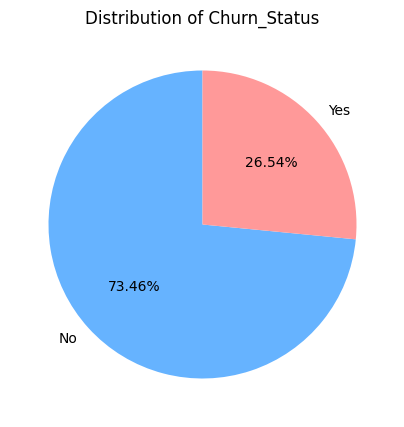

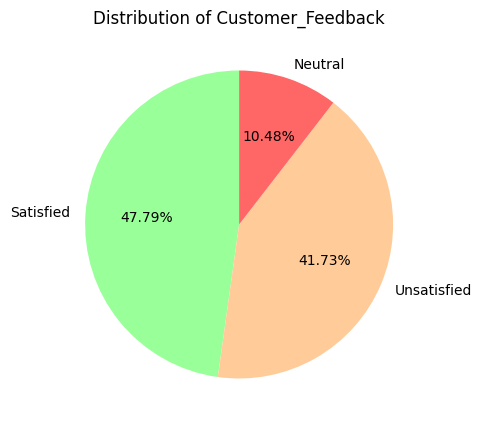

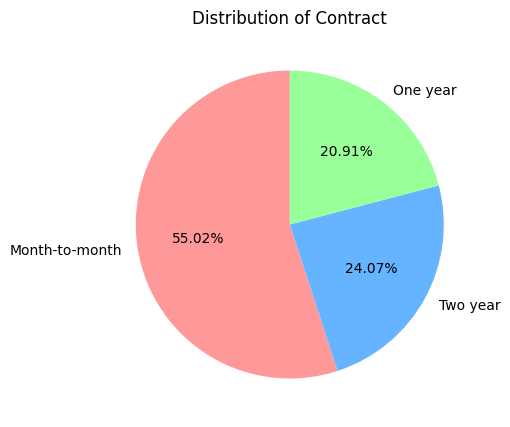

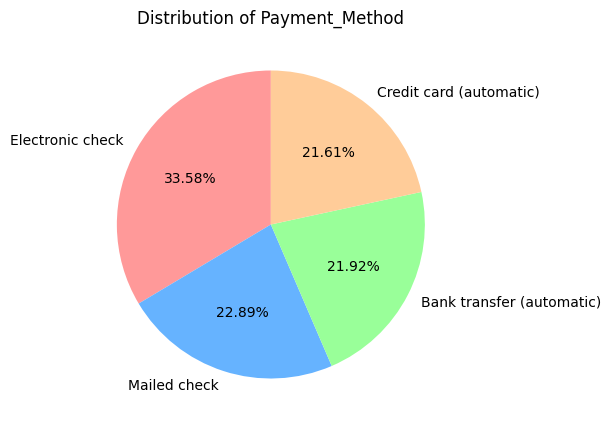

In [41]:
import matplotlib.pyplot as plt

pie_cols = ['Churn_Status', 'Customer_Feedback', 'Contract', 'Payment_Method']

colors_list = [
    ['#66b3ff', '#ff9999'], # churn_status
    ['#99ff99', '#ffcc99', '#ff6666'], # customer_feedback
    ['#ff9999', '#66b3ff', '#99ff99'], # contract
    ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'] # payment_method
]

for i, col in enumerate(pie_cols):
    plt.figure(figsize = (5, 5))
    counts = data[col].value_counts()
    plt.pie(counts, labels = counts.index, autopct = '%1.2f%%', startangle = 90, colors = colors_list[i])
    plt.title(f'Distribution of {col}')
    plt.show()

### Clustered Bar Charts

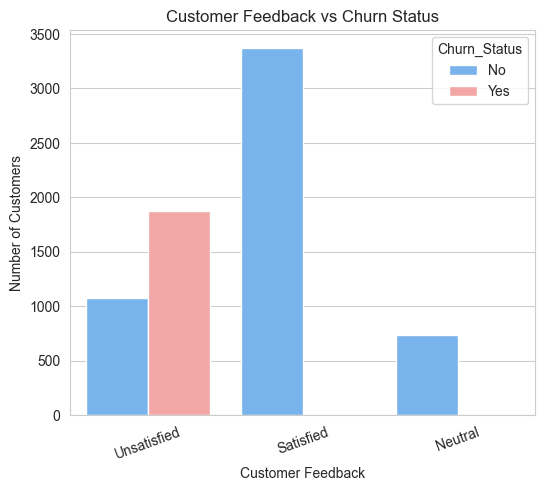

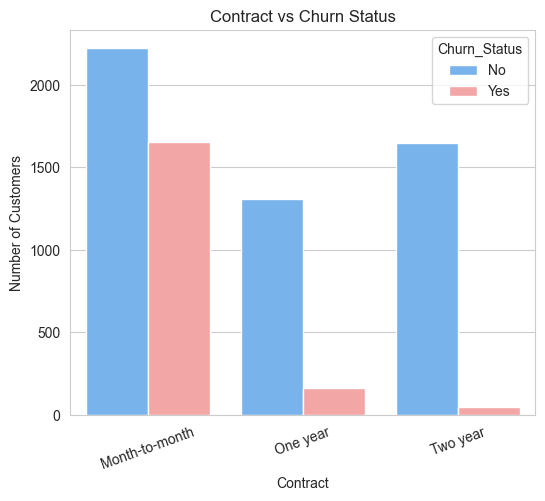

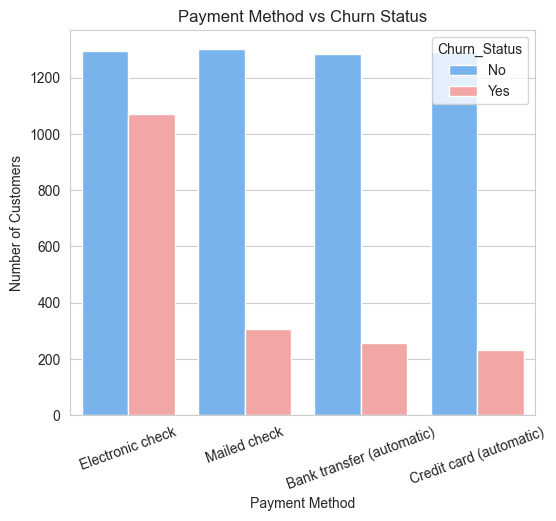

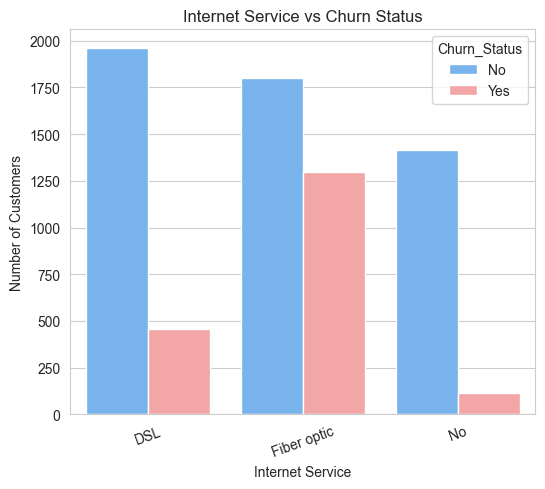

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# set style
sns.set_style('whitegrid')

# lists of categorical columns
condition_vars = ['Customer_Feedback', 'Contract', 'Payment_Method', 'Internet_Service']
for col in condition_vars:
    plt.figure(figsize = (6, 5))
    sns.countplot(data = data, x = col, hue = 'Churn_Status', palette = ['#66b3ff', '#ff9999'])
    plt.title(f'{col.replace('_', ' ').title()} vs Churn Status')
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel('Number of Customers')
    plt.legend(title = 'Churn_Status')
    plt.xticks(rotation = 20) # rotate labels if too long
    plt.show()

### Histogram

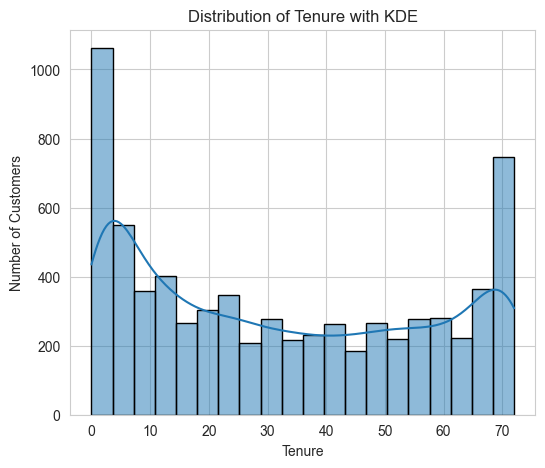

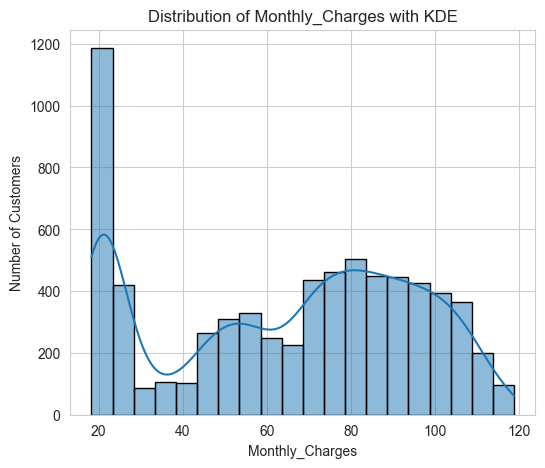

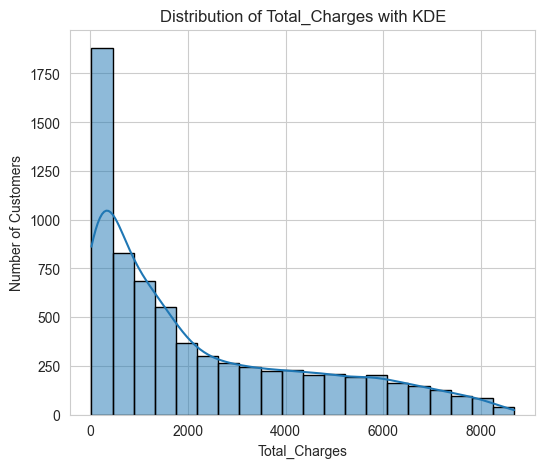

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

numeric_vars = ['Tenure', 'Monthly_Charges', 'Total_Charges']
for col in numeric_vars:
    plt.figure(figsize = (6, 5))
    sns.histplot(data[col], bins = 20, kde = True, edgecolor = 'black')
    plt.title(f'Distribution of {col} with KDE')
    plt.xlabel(col)
    plt.ylabel('Number of Customers')
    plt.show()

### KDE PLot

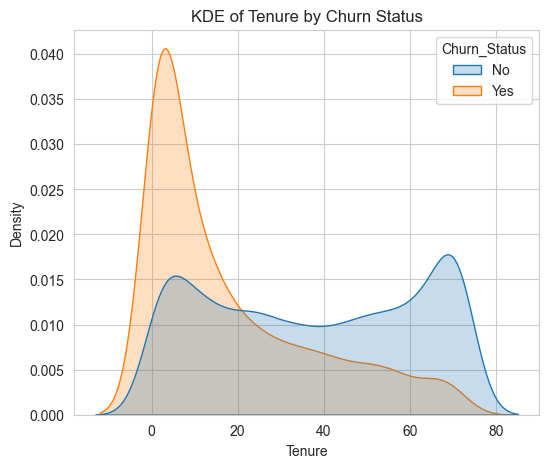

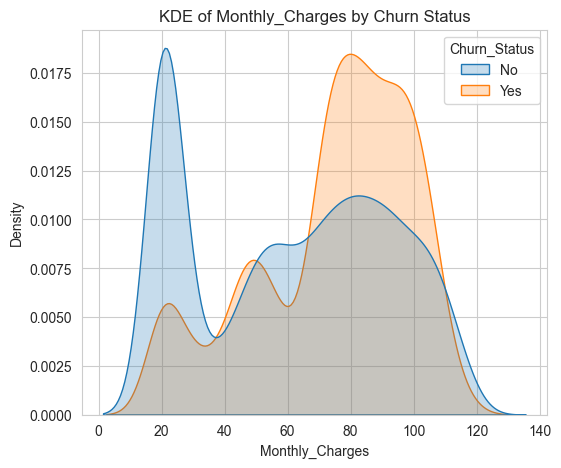

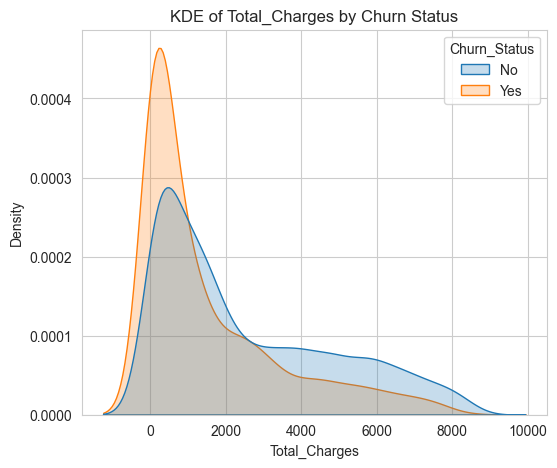

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

numeric_vars = ['Tenure', 'Monthly_Charges', 'Total_Charges']
for col in numeric_vars:
    plt.figure(figsize = (6, 5))
    sns.kdeplot(data = data, x = col, hue = 'Churn_Status', fill = True, common_norm = False)
    plt.title(f'KDE of {col} by Churn Status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

### Scatter Plot

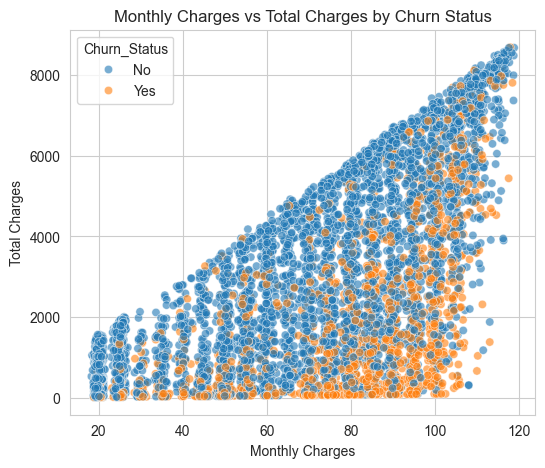

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

plt.figure(figsize = (6, 5))
sns.scatterplot(data = data, x = 'Monthly_Charges', y = 'Total_Charges', hue = 'Churn_Status', alpha = 0.6)
plt.title('Monthly Charges vs Total Charges by Churn Status')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.legend(title = 'Churn_Status')
plt.show()

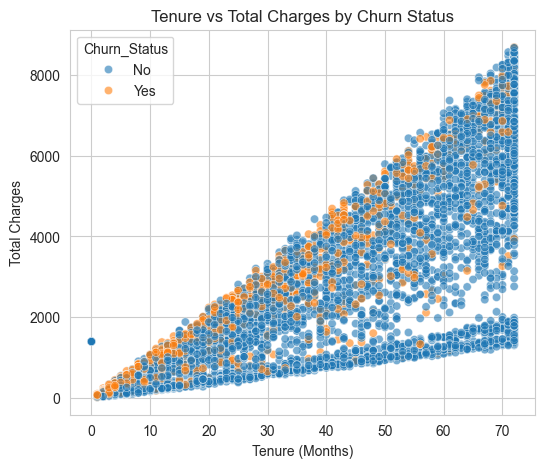

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

plt.figure(figsize = (6, 5))
sns.scatterplot(data = data, x = 'Tenure', y = 'Total_Charges', hue = 'Churn_Status', alpha = 0.6)
plt.title('Tenure vs Total Charges by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Total Charges')
plt.legend(title = 'Churn_Status')
plt.show()

### Box Plot

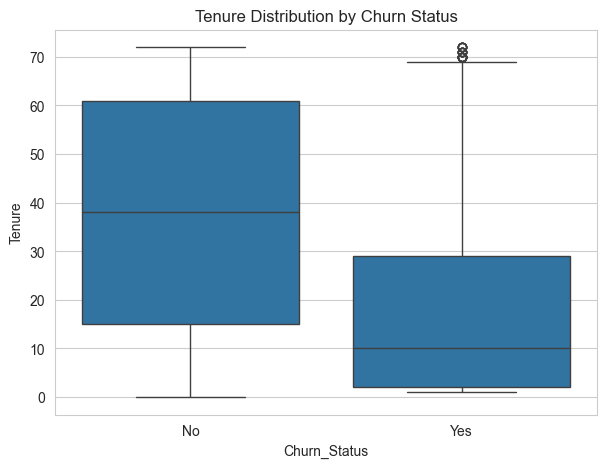

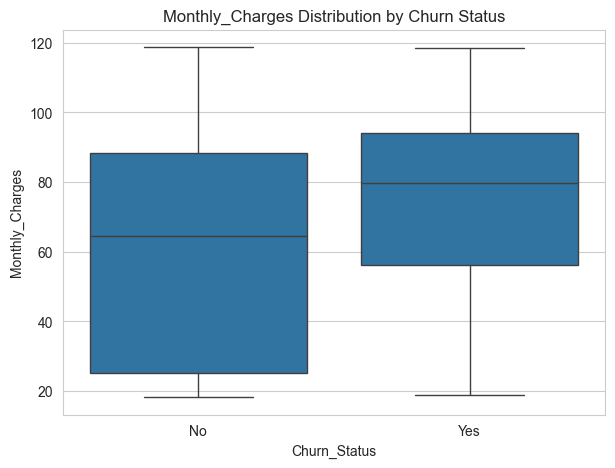

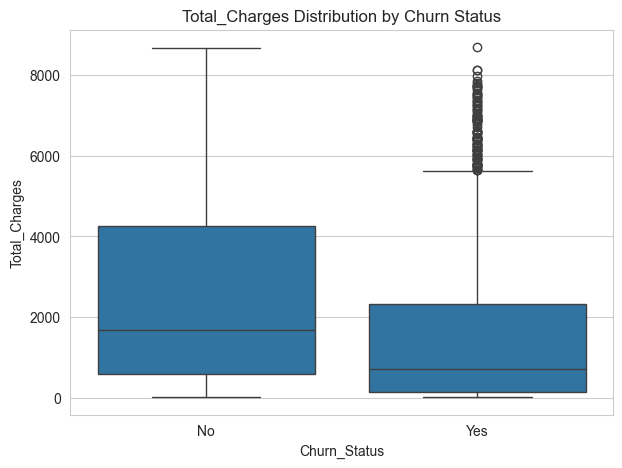

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

numeric_vars = ['Tenure', 'Monthly_Charges', 'Total_Charges']
for col in numeric_vars:
    plt.figure(figsize = (7, 5))
    sns.boxplot(data = data, x = 'Churn_Status', y  = col)
    plt.title(f'{col} Distribution by Churn Status')
    plt.xlabel('Churn_Status')
    plt.ylabel(col)
    plt.show()

### Correlation Heatmap

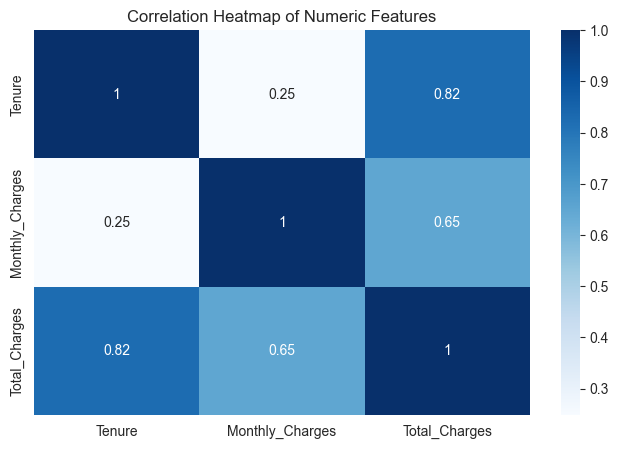

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 5))
sns.heatmap(correlation, annot = True, cmap = 'Blues')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [49]:
data.to_csv('C:/Users/user/Desktop/APROJECT/customer_churn_cleaned.csv', index = False)

In [50]:
data.head()

,Customer_ID,Gender,Senior_Citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Customer_Feedback,Churn_Status
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Unsatisfied,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,Satisfied,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Unsatisfied,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Satisfied,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Unsatisfied,Yes
